In [1]:
%reload_ext autoreload
%autoreload 2

from src.backtest import Backtest
from src.pattern import Pattern, Bollinger, High, GoldenCross, Trending, Disparity

# 기본설정

In [4]:
start = "2000-01-01"
end = "2025-12-31"
end_book = '2011-12-31'
bm = Pattern(name='모든주식')
bt = Backtest(start, end, benchmark=bm, db=1)

모든주식 | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

모든주식 | filter:   0%|          | 0/6409 [00:00<?, ?it/s]

모든주식 | dates:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 | filter:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 | dates:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 + 52주 고가 | filter:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 + 52주 고가 | dates:   0%|          | 0/6409 [00:00<?, ?it/s]

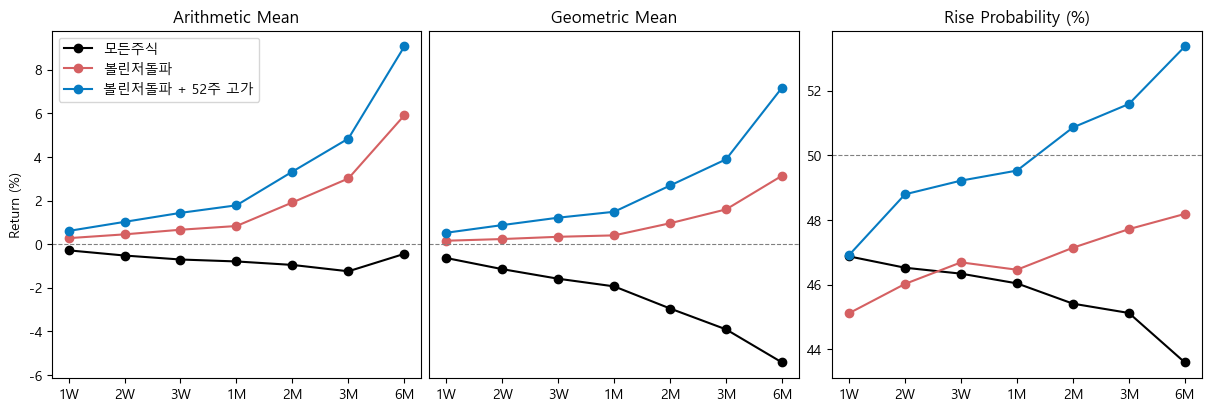

In [5]:
bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=252, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w

stats = bt.analyze(bb, bb_high52w, by='day',
                   marketcap_top_pct=0.7,
                   cohort_top_n=10,
                   top_n_type='liquidity'
                   )
stats.plot()

모든주식 | filter:   0%|          | 0/6409 [00:00<?, ?it/s]

모든주식 | dates:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 | filter:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 | dates:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 + 52주 고가 | filter:   0%|          | 0/6409 [00:00<?, ?it/s]

볼린저돌파 + 52주 고가 | dates:   0%|          | 0/6409 [00:00<?, ?it/s]

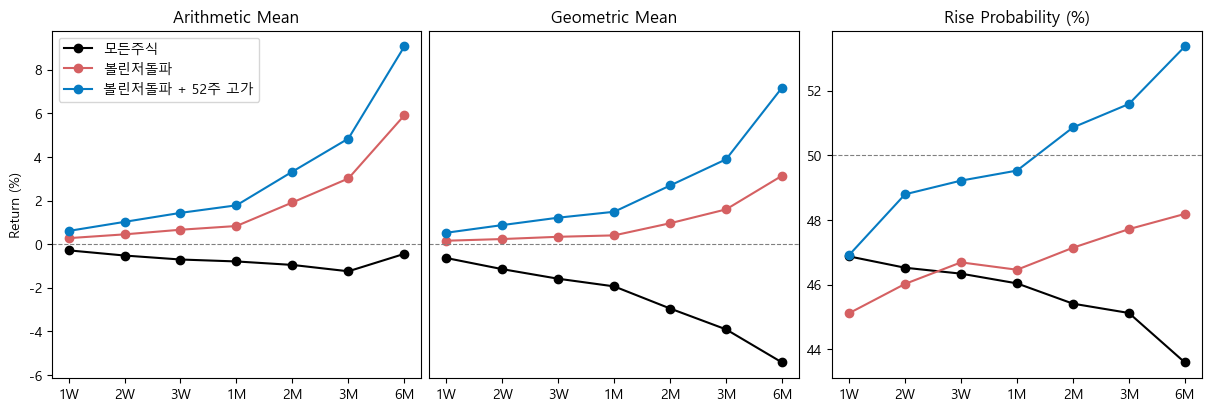

In [3]:
bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=252, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w

stats = bt.analyze(bb, bb_high52w, by='day',
                   marketcap_top_pct=0.7,
                   cohort_top_n=10,
                   top_n_type='liquidity'
                   )
stats.plot()

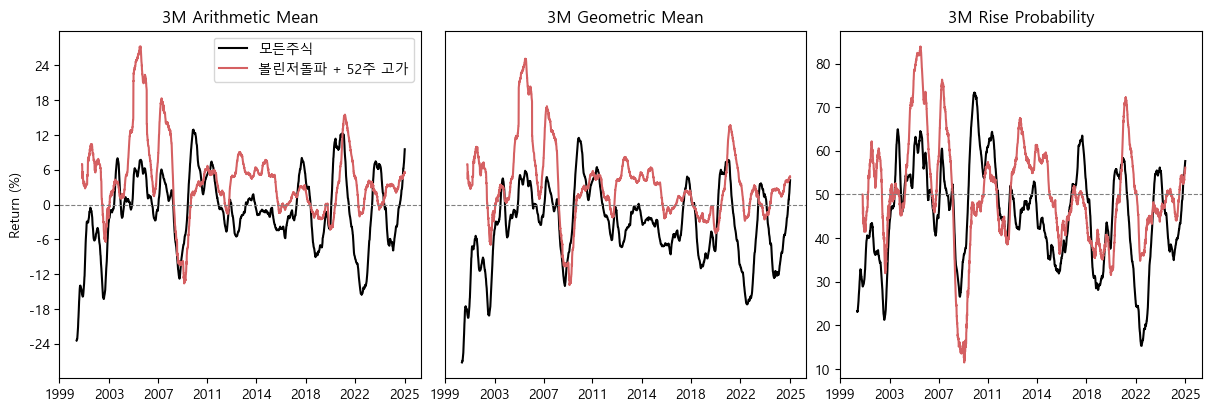

In [4]:
stats.plot_history(horizon='3M', patterns=['모든주식', '볼린저돌파 + 52주 고가'])

/root/miniconda3/envs/metricstudio/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


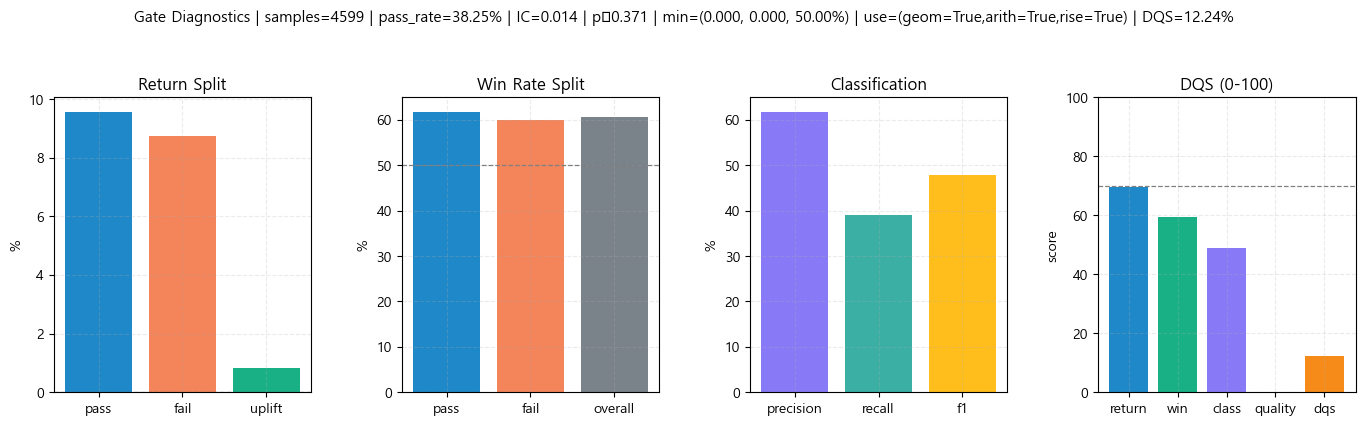

In [45]:
diag = bt.diagnose_gate(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=120,
    aggregate_lookback=120,
    trade_price_mode="당일종가",
    gate_use_arith=True,
    gate_use_geom=True,
    gate_use_rise=True,
)

diag.plot()

/root/miniconda3/envs/metricstudio/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8776 (\N{ALMOST EQUAL TO}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


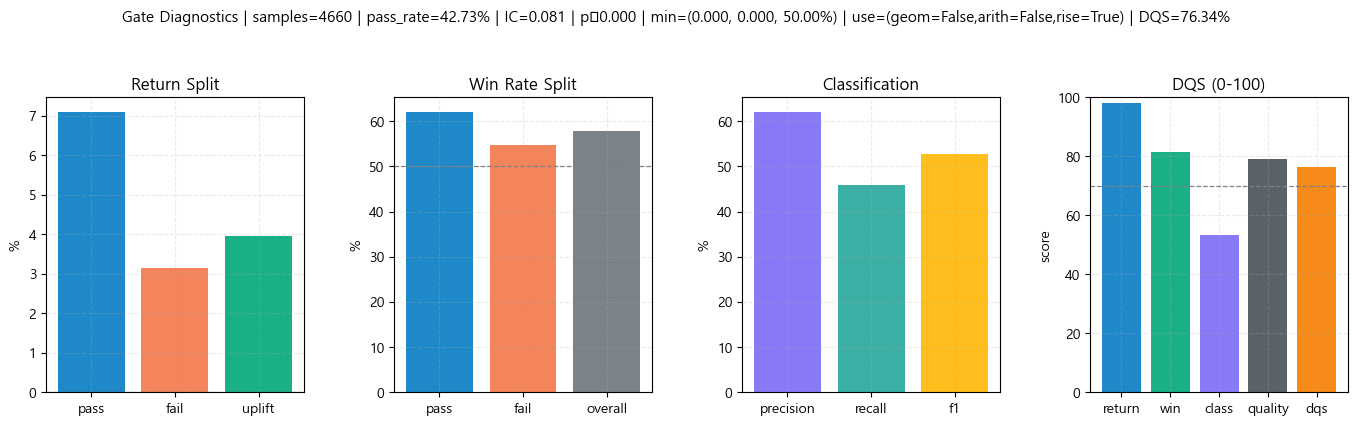

In [6]:
diag = bt.diagnose_gate(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=60,
    aggregate_lookback=60,
    trade_price_mode="당일종가",
    # gate_use_arith=True,
    # gate_use_geom=True,
    gate_use_rise=True,
)

diag.plot();

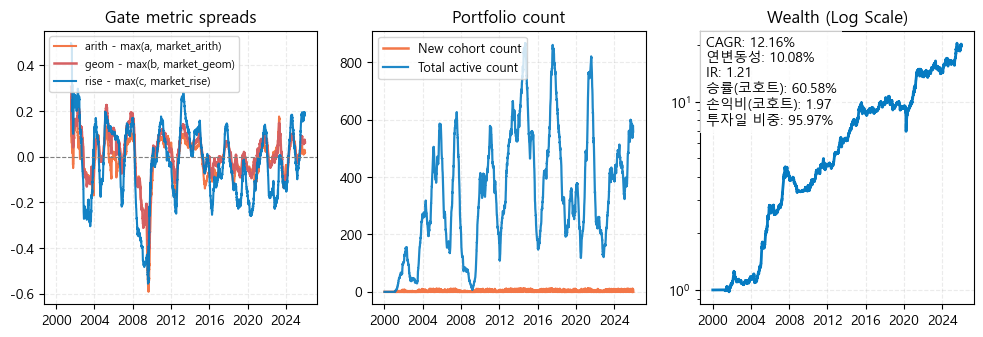

In [46]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=120,
    aggregate_lookback=120,
    fallback_exposure=1,
    trade_price_mode='당일종가',
    gate_use_arith=True,
    gate_use_geom=True,
    gate_use_rise=True,
)
simul.plot()

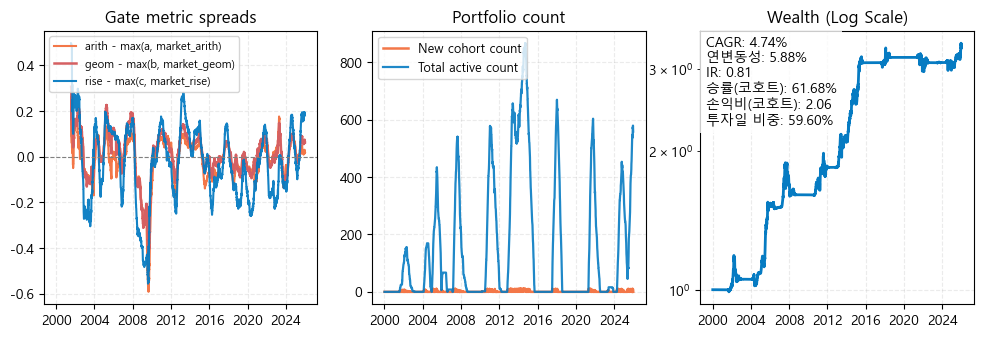

In [49]:
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=120,
    aggregate_lookback=120,
    fallback_exposure=0,
    trade_price_mode='당일종가',
    gate_use_arith=True,
    gate_use_geom=True,
    gate_use_rise=True,
    # gate_geom_min=0.02,
    # gate_arith_min=0.02,
    # gate_rise_min=0.55,
    # stop_loss_pct=0.05,
    # take_profit_pct=0.5,
)
simul.plot()

이평선252d 돌파 + 이평선 상향 | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

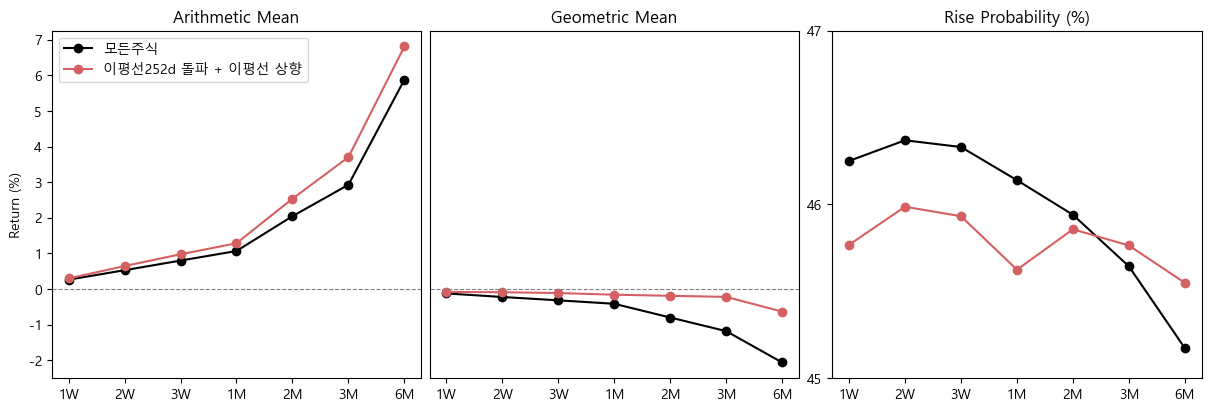

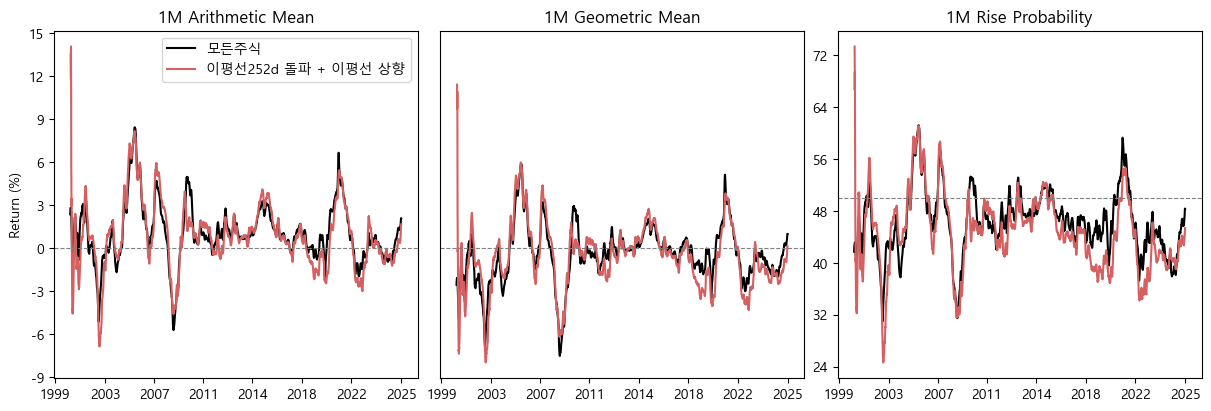

In [ ]:
ma = Trending(name='이평선252d 돌파').on(trigger='breakout_up', window=252, cooldown_days=3)
ma_u = Trending(name='이평선 상향').on(trigger='ma_trend_up', window=252, cooldown_days=3)
stats = bt.analyze(ma + ma_u)
stats.plot()
stats.plot_history(horizon='1M')

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


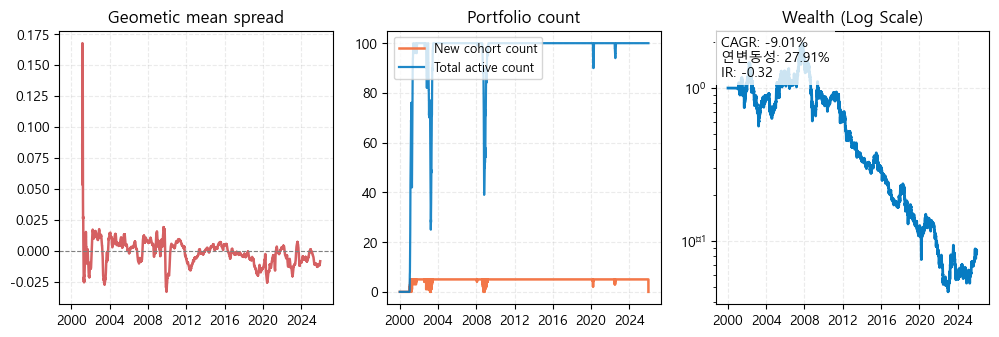

In [18]:
simul = bt.run(
    pattern="이평선252d 돌파 + 이평선 상향",
    target_horizon=20,
    aggregate_lookback=250,
    fallback_exposure=1,
    cohort_top_n=5,
    top_n_type="liquidity",
    marketcap_top_pct=0.7,
    trade_price_mode='당일종가'
)
simul.plot()

이격도 90% | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

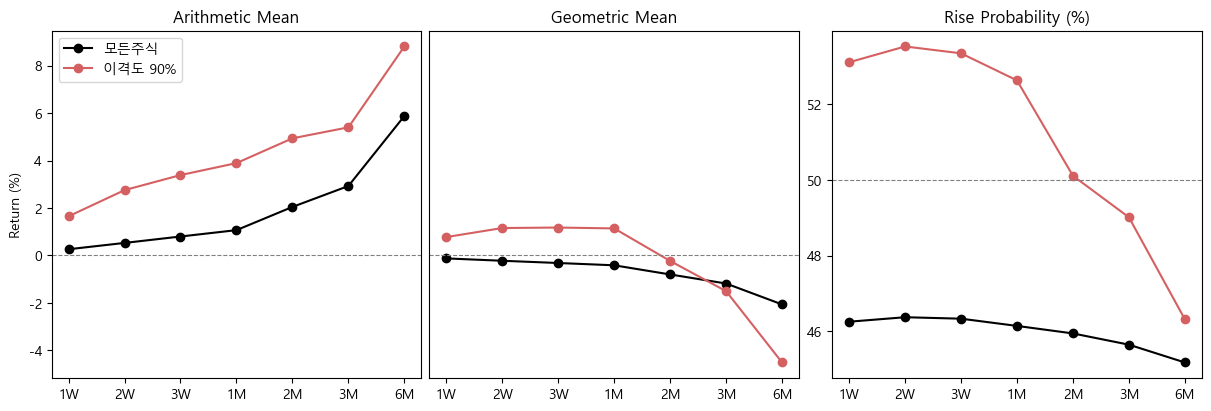

In [18]:
dp = Disparity(name="이격도 90%", window=20).on(threshold=0.9, stay_days=5, cooldown_days=5)
stats = bt.analyze(dp, by='event')
stats.plot()

모든주식 | trim:   0%|          | 0/6409 [00:00<?, ?it/s]

이격도 90% | trim:   0%|          | 0/6409 [00:00<?, ?it/s]

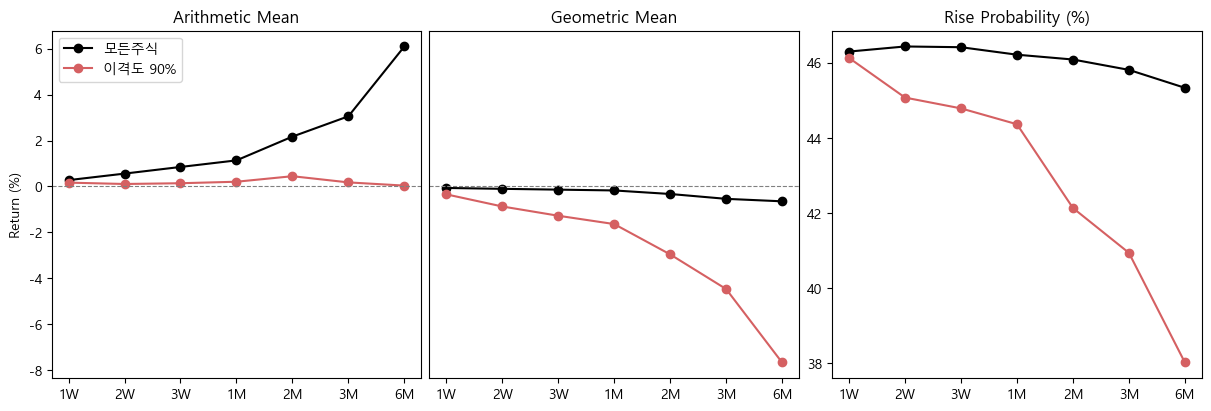

In [16]:
dp = Disparity(name="이격도 90%", window=20).on(threshold=0.9, stay_days=5, cooldown_days=5)
stats = bt.analyze(dp, by='day')
stats.plot()

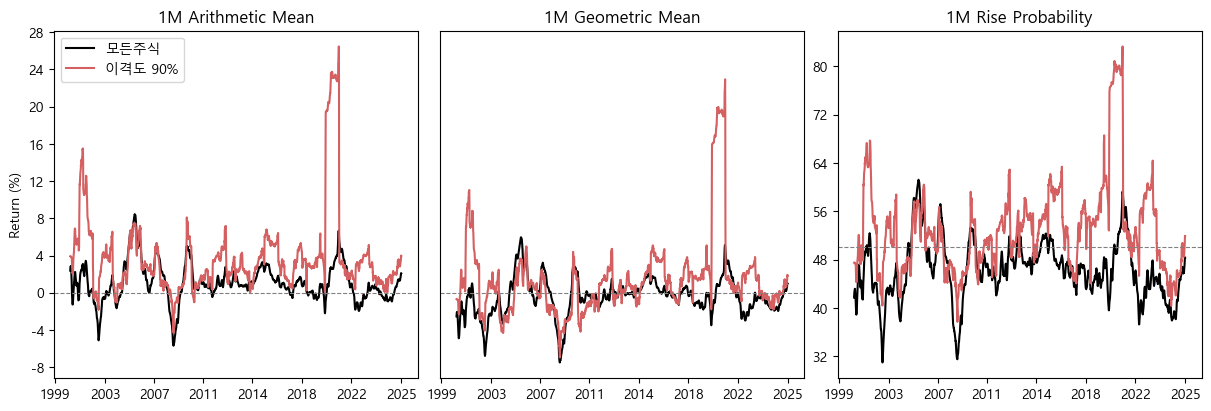

In [19]:
stats.plot_history(horizon='1M')

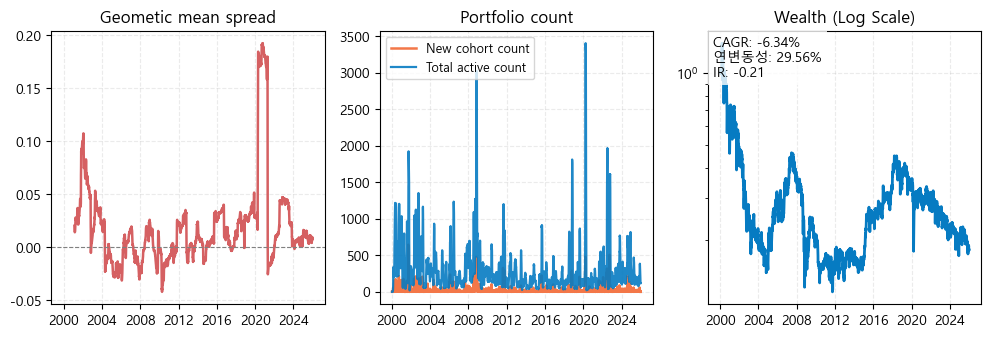

In [21]:
simul = bt.run(
    pattern="이격도 90%",
    target_horizon=20,
    aggregate_lookback=250,
    fallback_exposure=1,
    # cohort_top_n=5,
    # top_n_type="liquidity",
    # marketcap_top_pct=0.7,
    trade_price_mode='당일종가'
)
simul.plot()

In [22]:
simul.summary()

{'pattern': '이격도 90%',
 'target_horizon': '1M',
 'target_horizon_days': 20.0,
 'aggregate_lookback': '250',
 'fallback_exposure': 1.0,
 'stop_loss_pct': nan,
 'take_profit_pct': nan,
 'min_marketcap': nan,
 'marketcap_top_pct': nan,
 'execution_lag_days': 0.0,
 'execution_price_mode': 'same_close',
 'max_weight_per_stock': nan,
 'cohort_top_n': nan,
 'top_n_type': 'none',
 'allow_reentry': True,
 'min_cohort_size': 1.0,
 'buy_fee': 0.0003,
 'sell_fee': 0.002,
 'run_years': 25.987679671457904,
 'total_return': -0.8175103120696181,
 'cagr': -0.06336017633116431,
 'total_buy_fee_paid': 0.026453596799827426,
 'total_sell_fee_paid': 0.17476214597786704,
 'total_fee_paid': 0.20121574277769447}

### 이평선

##### 책 구간 (2000-2011)

이평선252d 돌파 + 이평선 상향 | codes:   0%|          | 0/3476 [00:00<?, ?it/s]

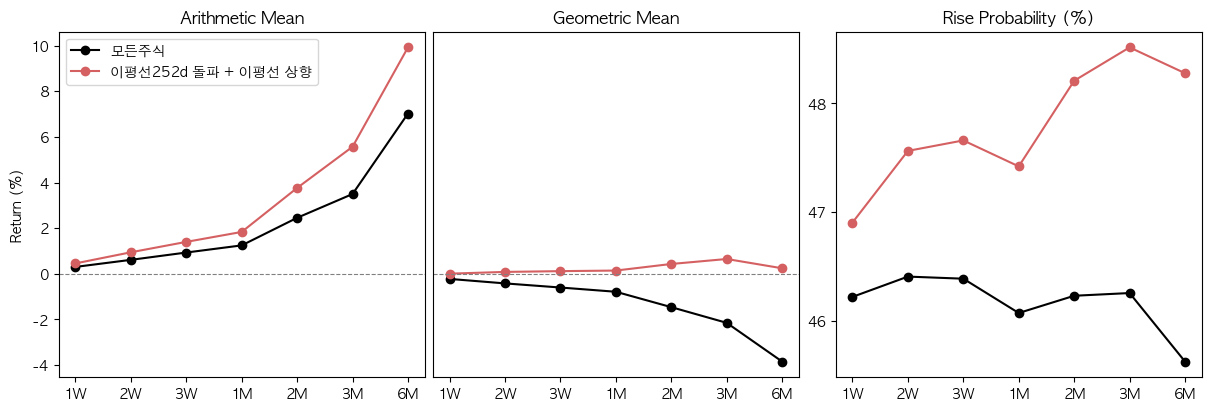

In [15]:
ma = Trending(name='이평선252d 돌파').on(trigger='breakout_up', window=252, cooldown_days=3)
ma_u = Trending(name='이평선 상향').on(trigger='ma_trend_up', window=252, cooldown_days=3)
stats = bt.analyze(ma + ma_u)
stats.plot(end=end_book)

##### 전체구간 (2000-2025)

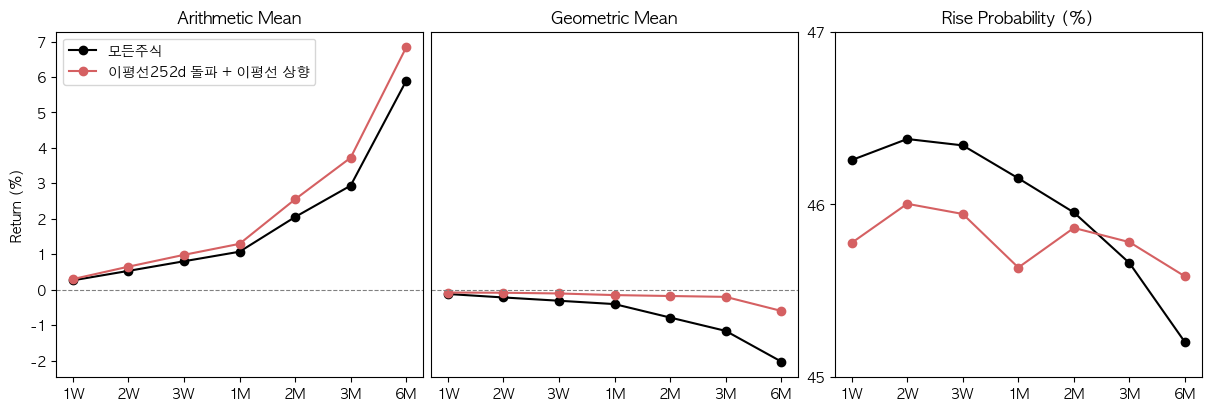

In [16]:
stats.plot()

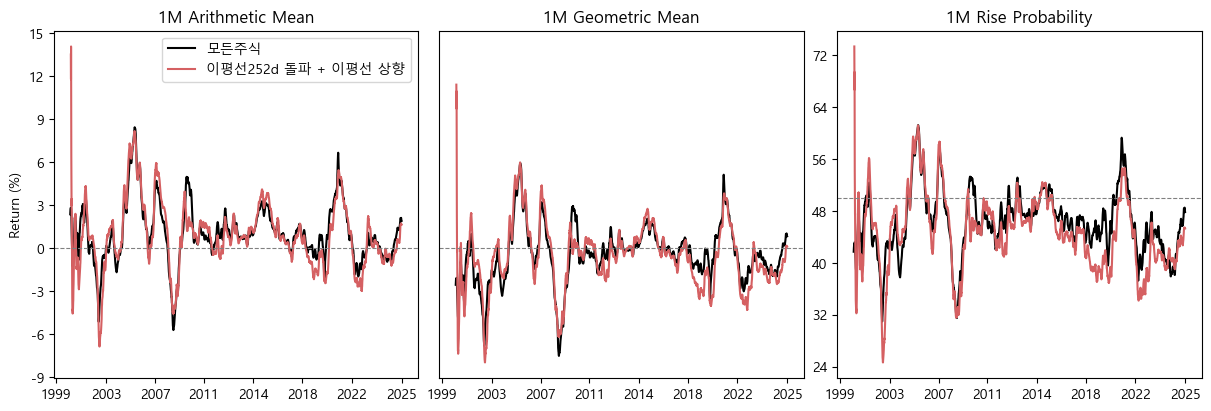

In [45]:
stats.plot_history(horizon='1M')

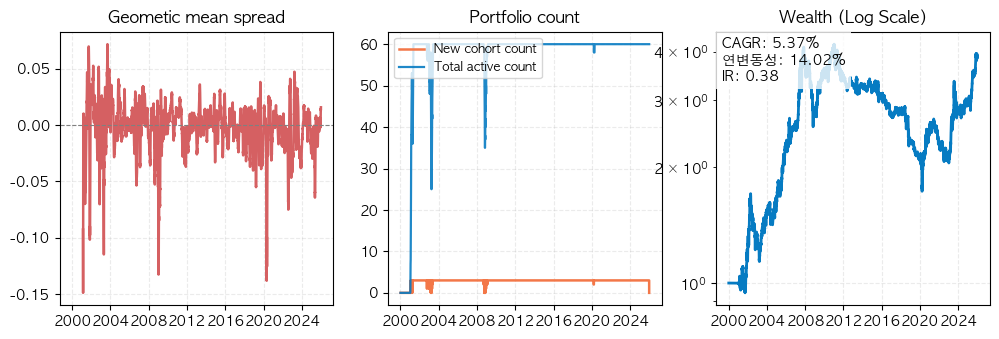

In [31]:
n = 20
simul = bt.run(
    pattern="이평선252d 돌파 + 이평선 상향",
    target_horizon=n,
    aggregate_lookback=20,
    # fallback_exposure=0.5,
    cohort_top_n=3,
    top_n_type="marketcap",
    marketcap_top_pct=0.7,
    trade_price_mode='당일종가',
    # stop_loss_pct=0.05,
    # take_profit_pct=0.2
)
simul.plot()

### 볼린저밴드

##### 책 구간 (2000-2011)

볼린저돌파 | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

볼린저돌파 + 52주 고가 | codes:   0%|          | 0/3499 [00:00<?, ?it/s]

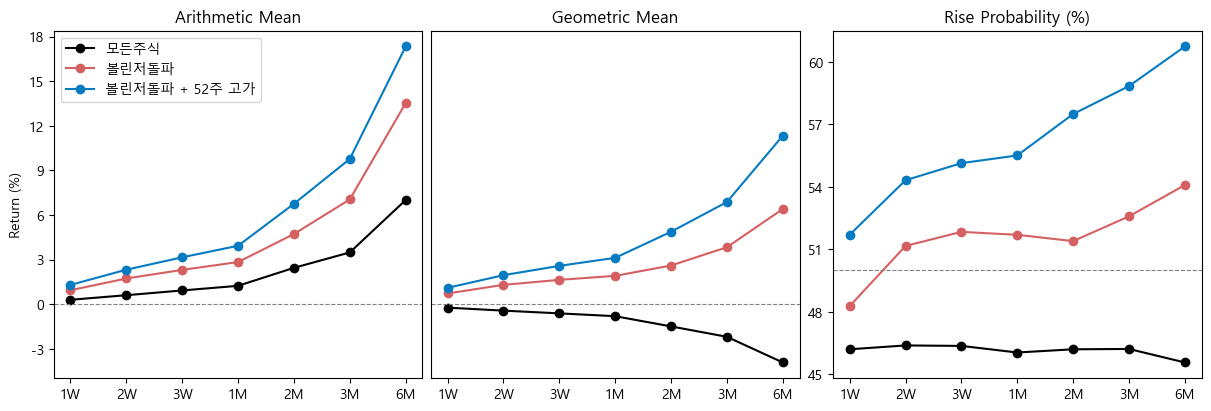

In [4]:
bb = Bollinger(name='볼린저돌파').on(trigger='breakout_up', breakout_cooldown_days=3, bandwidth_max=0.05)
high52w = High(name='52주 고가').on(window=252, threshold=0.90, stay_days=1)
bb_high52w = bb + high52w

stats = bt.analyze(bb, bb_high52w)
stats.plot(end=end_book)

##### 전체구간 (2000-2025)

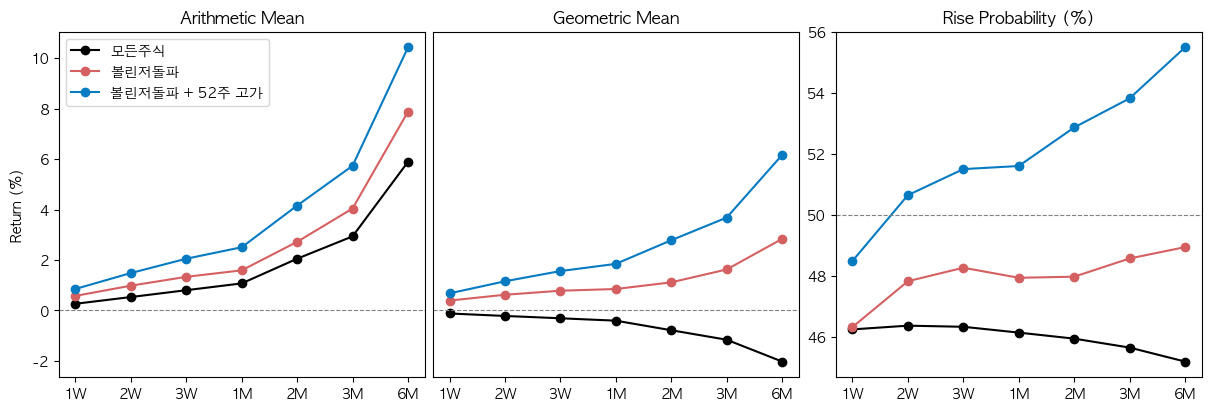

In [4]:
stats.plot()

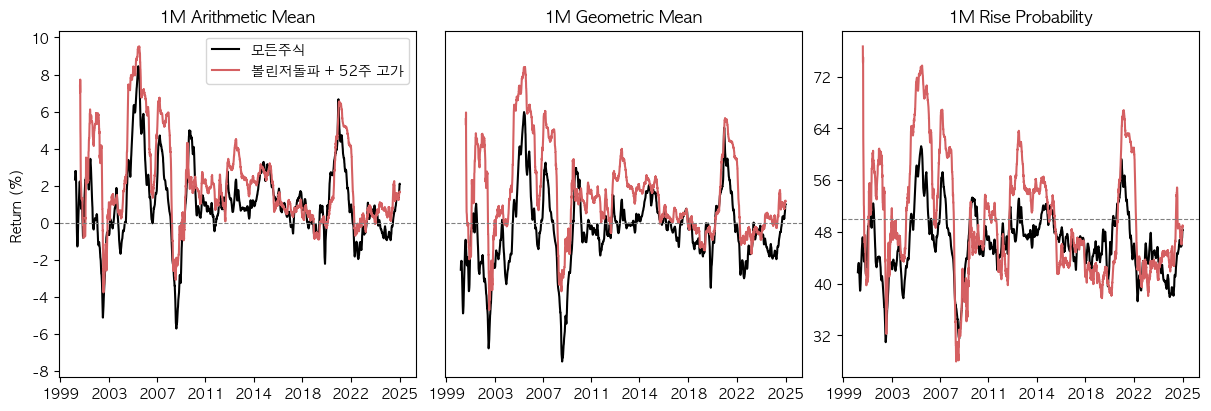

In [5]:
stats.plot_history(horizon='1M', patterns=['모든주식', '볼린저돌파 + 52주 고가'])

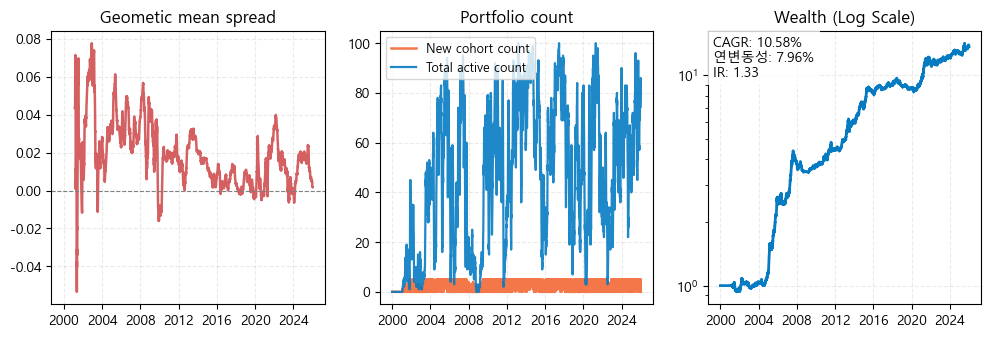

In [8]:
n = 20
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=n,
    # aggregate_lookback=250,
    # fallback_exposure=1,
    cohort_top_n=5,
    top_n_type="liquidity",
    marketcap_top_pct=0.7,
    trade_price_mode='당일종가',
    # stop_loss_pct=0.05,
    # take_profit_pct=0.2
)
simul.plot()

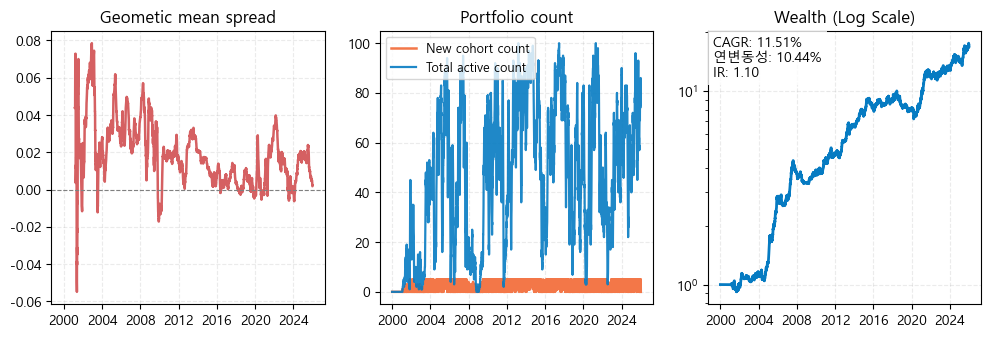

In [6]:
n = 20
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=n,
    aggregate_lookback=250,
    fallback_exposure=1,
    cohort_top_n=5,
    top_n_type="liquidity",
    marketcap_top_pct=0.7,
    trade_price_mode='익일종가',
    # stop_loss_pct=0.05,
    # take_profit_pct=0.2
)
simul.plot()

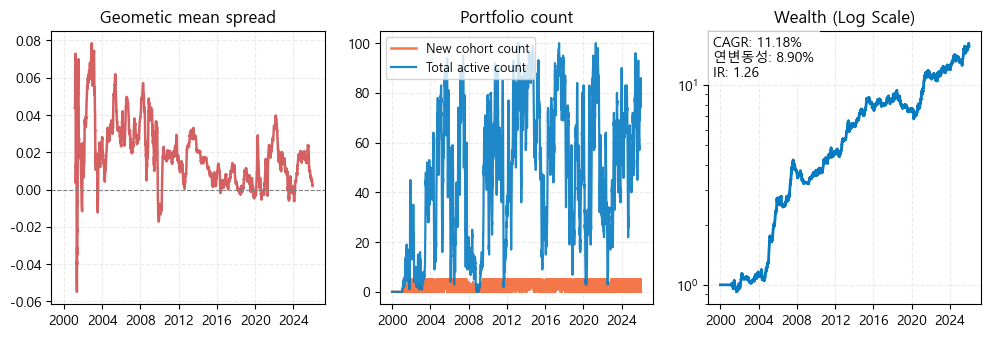

In [7]:
n = 20
simul = bt.run(
    pattern="볼린저돌파 + 52주 고가",
    target_horizon=n,
    aggregate_lookback=250,
    fallback_exposure=1,
    cohort_top_n=5,
    top_n_type="liquidity",
    marketcap_top_pct=0.7,
    trade_price_mode='익일VWAP',
    # stop_loss_pct=0.05,
    # take_profit_pct=0.2
)
simul.plot()

In [11]:
port = simul.port_at(date='2025-06-30'); port

code      name     value  entry_value  \
cohort_id entry_date age                                            
4592      2025-05-30 19   316140    우리금융지주  0.182376     0.156543   
                     19   024110      기업은행  0.181606     0.156543   
                     19   138930   BNK금융지주  0.176217     0.156543   
                     19   139130    iM금융지주  0.176163     0.156543   
                     19   037710     광주신세계  0.164796     0.156543   
...                          ...       ...       ...          ...   
4609      2025-06-26 2    014280      금강공업  0.161729     0.164548   
                     2    126880  제이엔케이글로벌  0.160688     0.164548   
4610      2025-06-27 1    023450      동남합성  0.399315     0.401069   
                     1    111770      영원무역  0.398546     0.401069   
4611      2025-06-30 0    030200        KT  0.820435     0.820435   

                          cohort_value  weight_in_cohort  
cohort_id entry_date age                                  
4592      2025-05-30 19       0.881158          0.206973  
                     19       0.881158          0.206099  
                     19       0.881158          0.199983  
                     19       0.881158          0.199922  
                     19       0.881158          0.187023  
...                                ...               ...  
4609      2025-06-26 2        0.814167          0.198643  
                     2        0.814167          0.197365  
4610      2025-06-27 1        0.797861          0.500482  
                     1        0.797861          0.499518  
4611      2025-06-30 0        0.820435          1.000000  

[73 rows x 6 columns]

In [29]:
port.xs(4775)

code     name     value  entry_value  cohort_value  \
entry_date age                                                         
2025-05-30 19   316140   우리금융지주  0.268085     0.230111      1.296826   
           19   024110     기업은행  0.266952     0.230111      1.296826   
           19   138930  BNK금융지주  0.259031     0.230111      1.296826   
           19   139130   iM금융지주  0.258952     0.230111      1.296826   
           19   034310     NICE  0.243806     0.230111      1.296826   

                weight_in_cohort  
entry_date age                    
2025-05-30 19           0.206724  
           19           0.205850  
           19           0.199742  
           19           0.199682  
           19           0.188002

### 이격도

##### 책 구간 (2000-2011)

이격도 90% | codes:   0%|          | 0/3476 [00:00<?, ?it/s]

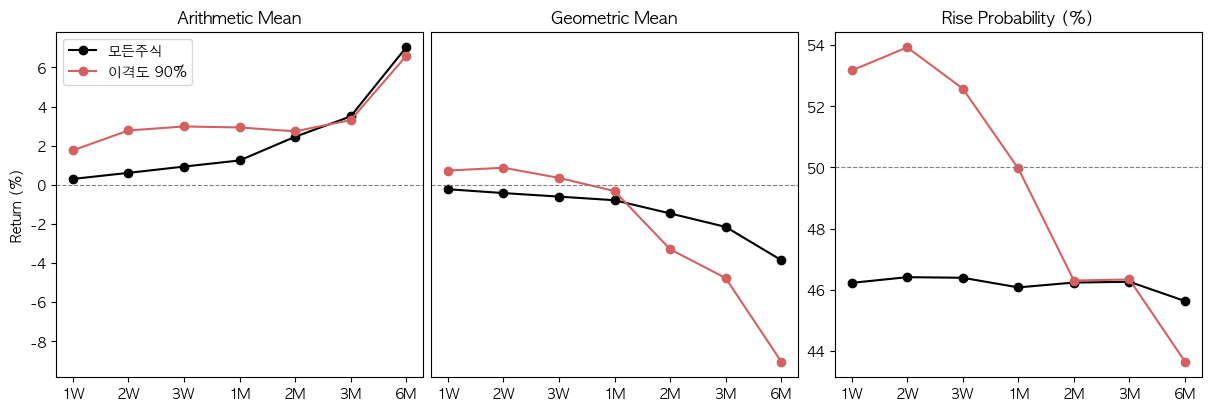

In [9]:
dp = Disparity(name="이격도 90%", window=20).on(threshold=0.9, stay_days=5, cooldown_days=5)
stats = bt.analyze(dp)
stats.plot(end=end_book)

##### 전체구간 (2000-2025)

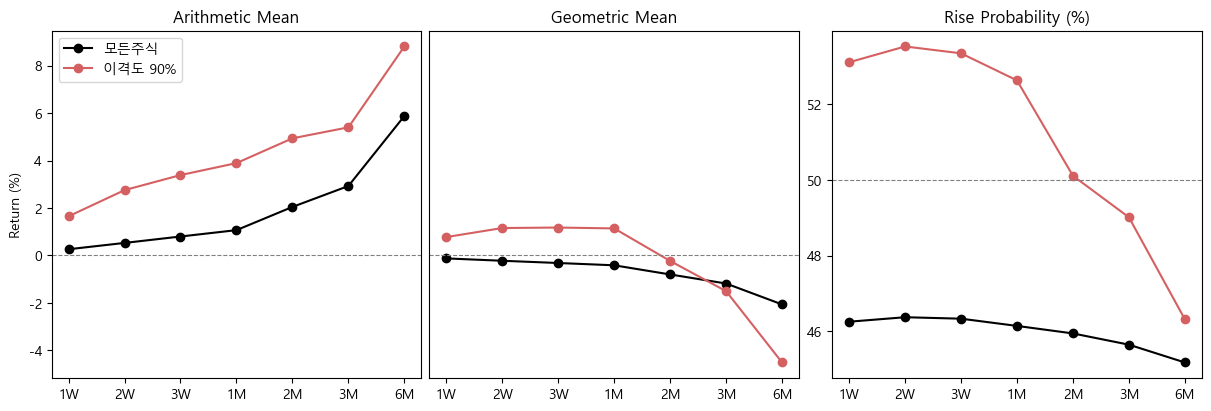

In [63]:
stats.plot()

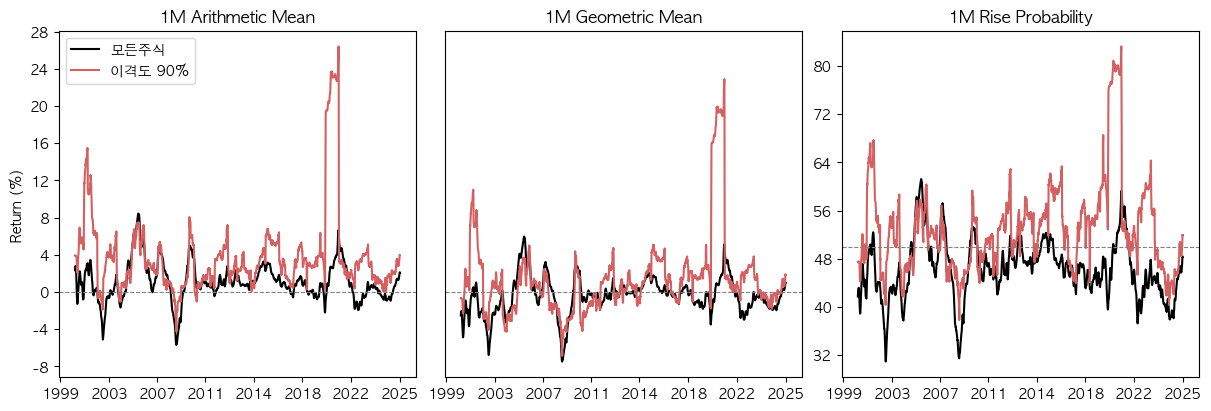

In [14]:
stats.plot_history(horizon='1M', patterns=['모든주식', '이격도 90%'])

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

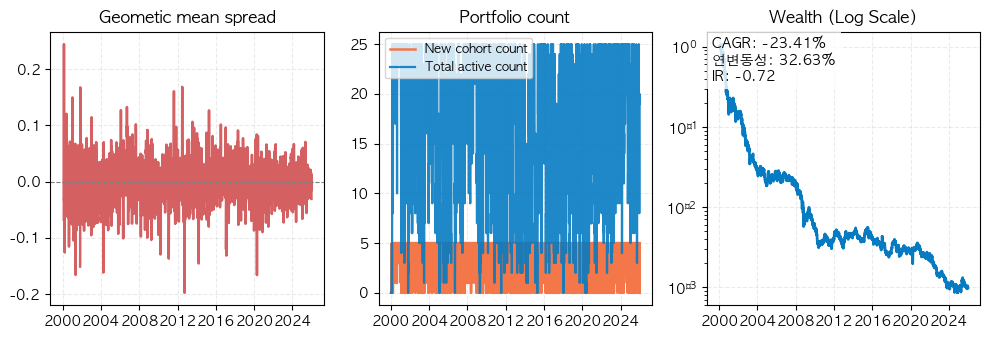

In [13]:
n = 5
simul = bt.run(
    pattern="이격도 90%",
    target_horizon=n,
    aggregate_lookback=n,
    fallback_exposure=1,
    cohort_top_n=5,
    top_n_type="liquidity",
    marketcap_top_pct=0.7,
    trade_price_mode='익일VWAP',
    # stop_loss_pct=0.05,
    # take_profit_pct=0.2
)
simul.plot()